# Test QEC System Info

In [1]:
import sys
from pathlib import Path

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import stim

from lightstim.qec_code.surface_code.rotated import (
    RotatedSurfaceCode,
    RotatedSurfaceCodeExtractionBlock,
)
from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
    UnrotatedTwoPatchCoupler,
)
from lightstim.qec_code.repetition import RepetitionCode
from lightstim.ir.qec_system import QECSystem
from lightstim.protocols.memory import MemoryExperiment
from lightstim.noise.config import NoiseConfig


In [2]:
noise_level = 0.001
noise_params = NoiseConfig(
    p_idle=noise_level,
    p_meas=noise_level,
    p_reset=noise_level,
    p_1q=noise_level,
    p_2q=noise_level
)

### 1. Multi-Patch Rotated Surface Code System

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Measuring data qubits...
Injecting noise...


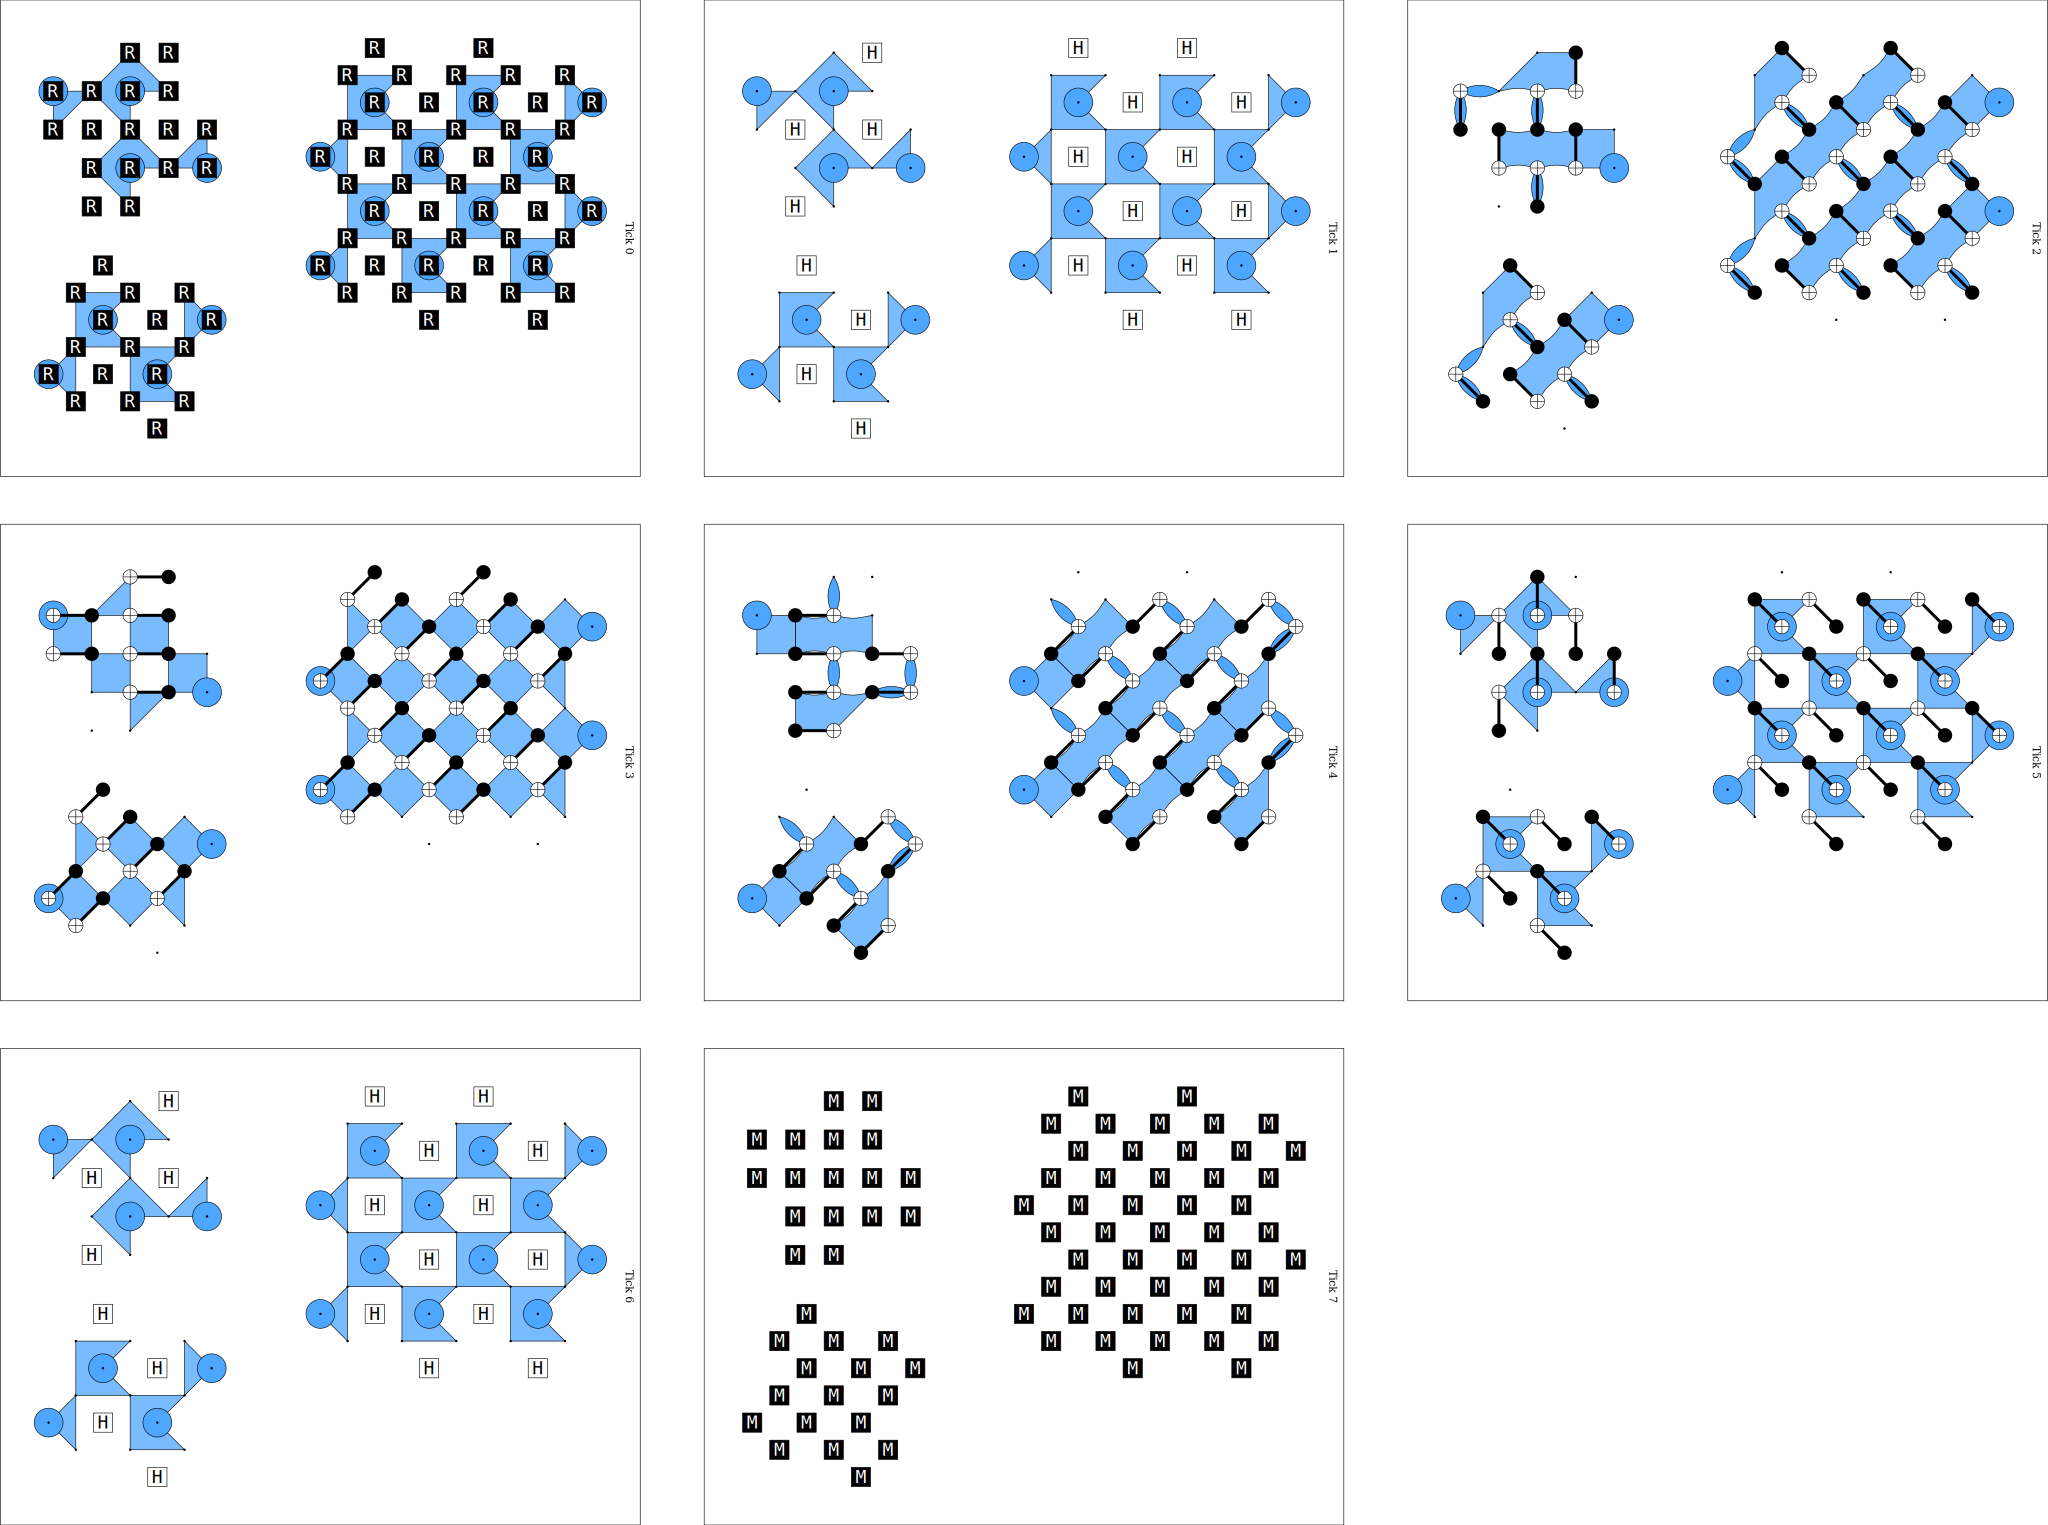

In [3]:
surface_code_1 = RotatedSurfaceCode(distance=3)
# surface_code_1.transpose_coords()
surface_code_1.rotate_coords(theta=np.pi/4)
surface_code_2 = RotatedSurfaceCode(distance=5)
surface_code_3 = RotatedSurfaceCode(distance=3)
system = QECSystem()
patch_1 = system.add_patch(surface_code_1, name = "surface_code_1")
patch_2 = system.add_patch(surface_code_2, offset=(10, 0), name = "surface_code_2")
patch_3 = system.add_patch(surface_code_3, offset=(0, 8), name = "surface_code_3")
# The above patches are the copies of the original patches after shift;
# The original patches are still in the original positions and can be reused elsewhere.

mem_exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    rounds=1,
    noise_params=noise_params,
    noise_model='circuit_level',
    basis='Z', # "Z" or "X"
    )
mem_circuit_rotated_SF = mem_exp.build()
mem_circuit_rotated_SF.without_noise().diagram("detslice-with-ops-svg")

### 2. Multi-Patch Unrotated Surface Code System

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Measuring data qubits...
Injecting noise...


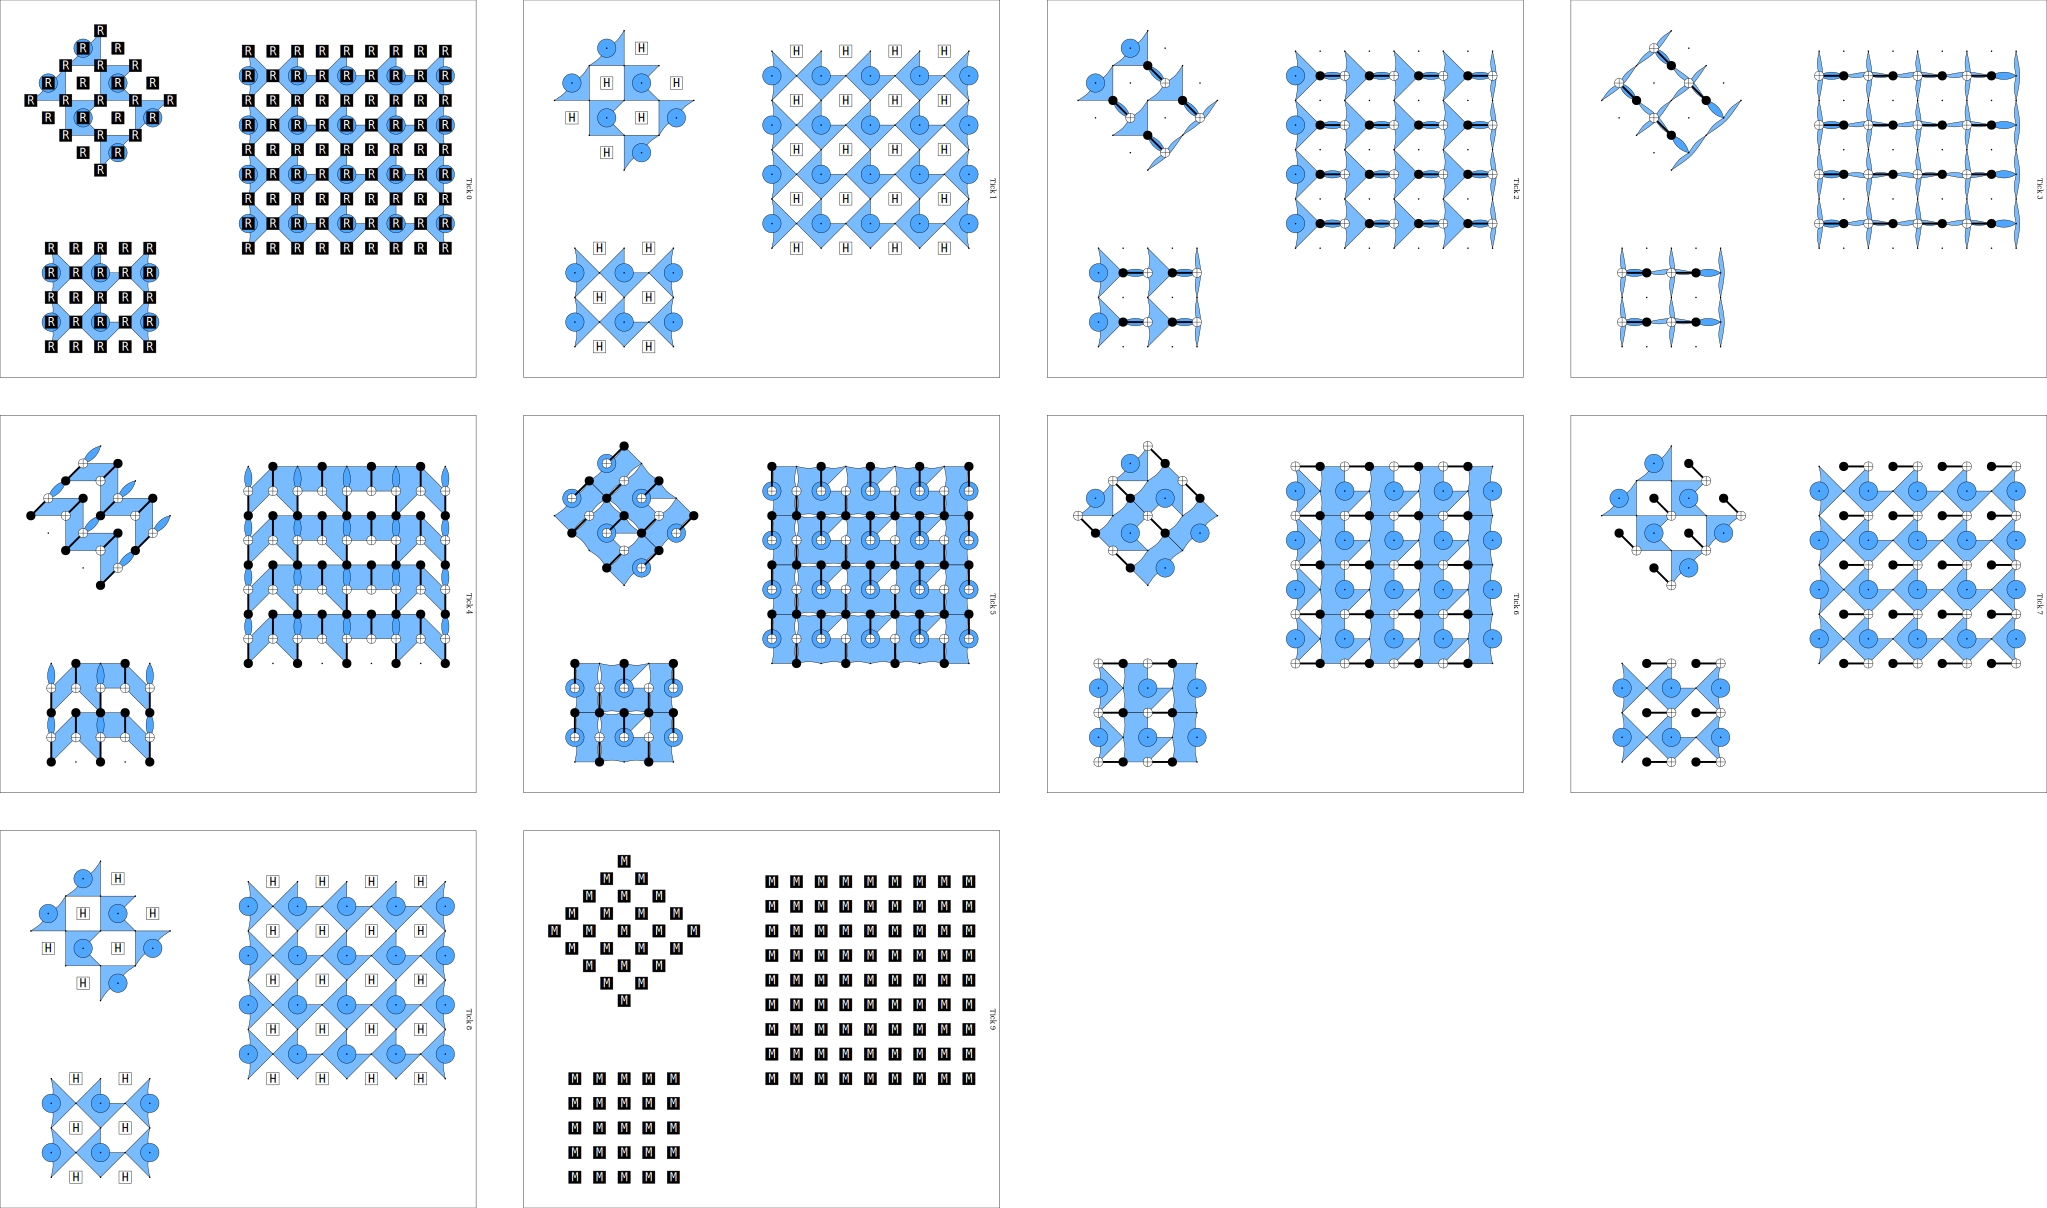

In [4]:
surface_code_1 = UnrotatedSurfaceCode(distance=3)
surface_code_1.rotate_coords(np.pi/4)
surface_code_2 = UnrotatedSurfaceCode(distance=5)
surface_code_3 = UnrotatedSurfaceCode(distance=3)
system = QECSystem()
patch_1 = system.add_patch(surface_code_1, name = "surface_code_1")
patch_2 = system.add_patch(surface_code_2, offset=(8, 0), name = "surface_code_2")
patch_3 = system.add_patch(surface_code_3, offset=(0, 8), name = "surface_code_3")

mem_exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
    rounds=1,
    noise_params=noise_params,
    noise_model='circuit_level',
    basis='Z', # "Z" or "X"
    )
mem_circuit_rotated_SF = mem_exp.build()
mem_circuit_rotated_SF.without_noise().diagram("detslice-with-ops-svg")

### 3. Change Logical Operator Location: Rotate, Reset Rotation Angle

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Measuring data qubits...
Injecting noise...


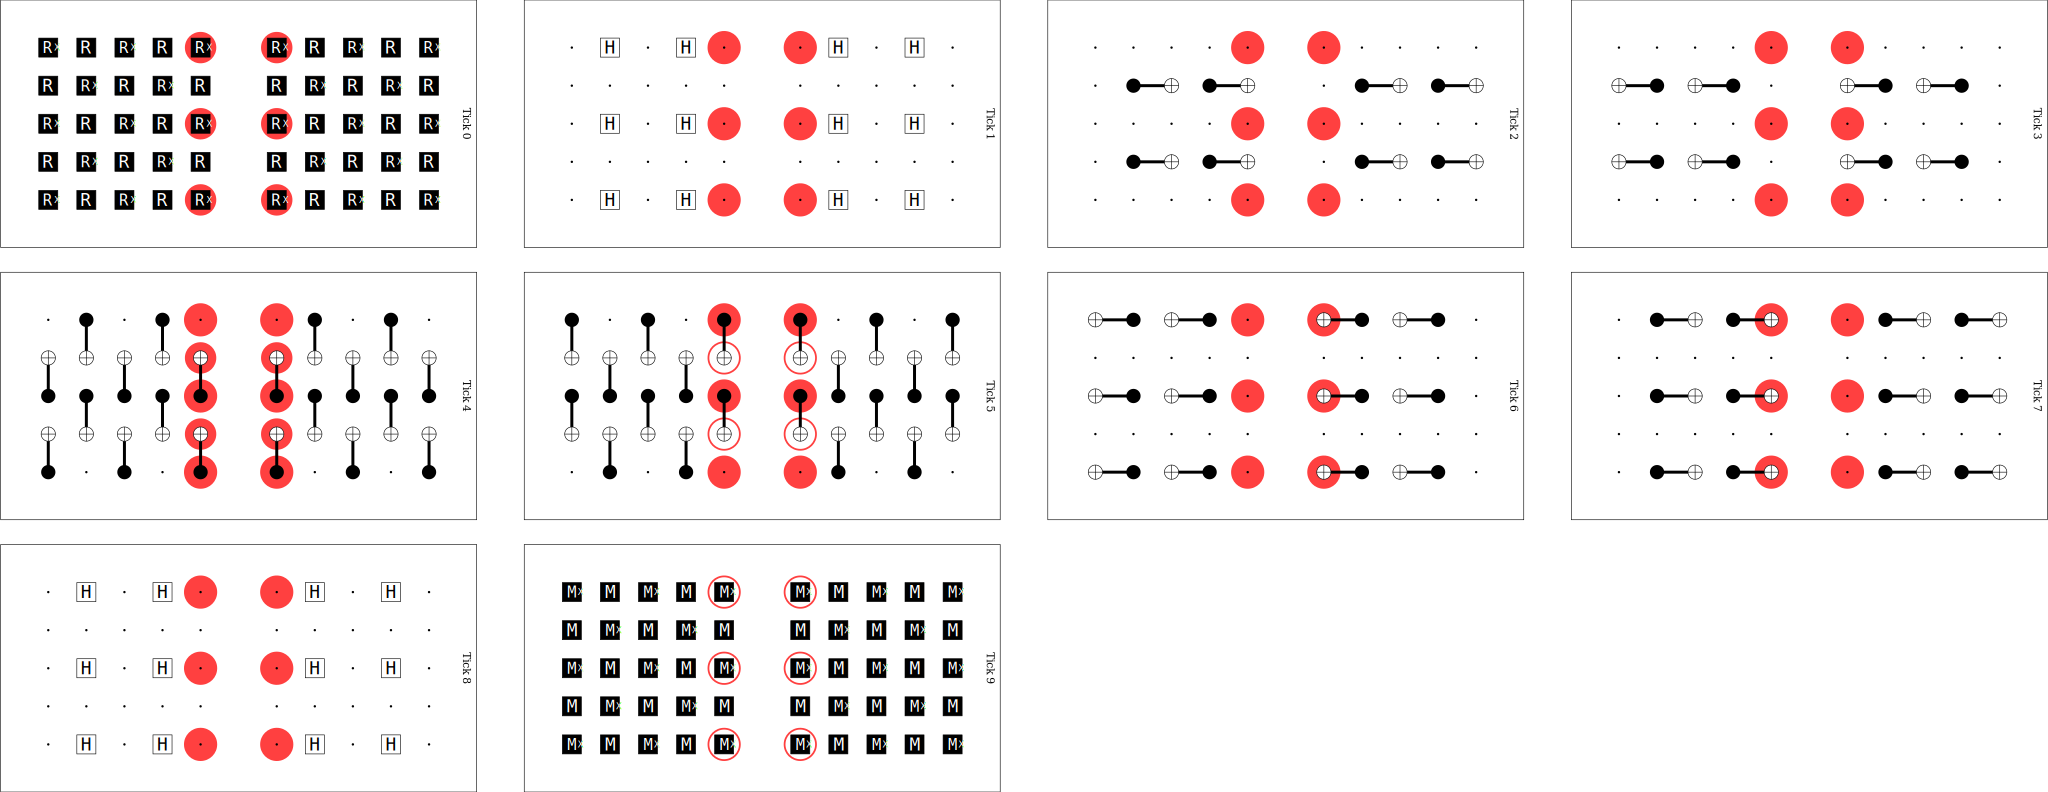

In [5]:
surface_code_1 = UnrotatedSurfaceCode(distance=3)
surface_code_1.rotate_coords(np.pi)
surface_code_1.reset_rotation_angle()
surface_code_2 = UnrotatedSurfaceCode(distance=3)
system = QECSystem()
patch_1 = system.add_patch(surface_code_1, name = "surface_code_1")
patch_2 = system.add_patch(surface_code_2, offset=(6, 0), name = "surface_code_2")

mem_exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
    rounds=1,
    noise_params=noise_params,
    noise_model='circuit_level',
    basis='X', # "Z" or "X"
    )
mem_circuit_rotated_SF = mem_exp.build()
mem_circuit_rotated_SF.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0","L1"])